# !!! Notes amélioration données !!!
- Enlever les outliers centre médicaux
- Réintégrer le ENERGYSTARScore
- Normaliser la donnée
- transformer la donnée
- Modififer le type d'encodage
- train test split 'paramétré'
- Number of building = 1

# Analyse Exploratoire

## Import des modules

In [1520]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

pd.set_option('display.max_columns',None)

## Analyse Exploratoire

In [1521]:
building_consumption = pd.read_csv('2016_Building_Energy_Benchmarking.csv')

In [1522]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [1523]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [1524]:
building_consumption.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

In [1525]:
df = building_consumption.copy()

## Suppression lignes

### Suppresion des lignes residentielles

In [1526]:
dict_BuildingType = {
    'NonResidential' : 'Non-Residential',
    'Multifamily LR (1-4)' :'Residential',
    'Multifamily MR (5-9)' :'Residential',
    'Multifamily HR (10+)': 'Residential',
    'SPS-District K-12' : 'Non-Residential',
    'Nonresidential COS' :'Non-Residential',
    'Campus' :'Non-Residential',
    'Nonresidential WA' :'Non-Residential'
}
df['BuildingType']=df['BuildingType'].map(dict_BuildingType)

df = df.loc[df['BuildingType'] == 'Non-Residential',:]
df.shape

(1668, 46)

In [1527]:
df = df.loc[(df['PrimaryPropertyType']!='Low-Rise Multifamily') & (df['PrimaryPropertyType']!='Residence Hall'),:] # Résidence universitaire
df.shape

(1644, 46)

### Suppression d'ENERGYSTARScore temporaire

In [1528]:
# df.drop('ENERGYSTARScore',axis=1, inplace=True)

### Suppression de lignes outliers == something

In [1529]:
df = df.loc[df['Outlier'].isna(),:]
df.shape

(1628, 46)

### Suppression des lignes non compliant

In [1530]:
df = df.loc[df['ComplianceStatus']=='Compliant',:]
df.shape

(1525, 46)

## Suppression colonnes inutiles

In [1531]:
First_column_to_drop = ['OSEBuildingID', 'DataYear','DefaultData', 'Comments', 'ComplianceStatus','Outlier',"BuildingType",'City','State','TaxParcelIdentificationNumber','ListOfAllPropertyUseTypes','NaturalGas(therms)','Electricity(kWh)','YearsENERGYSTARCertified','PrimaryPropertyType','Address','ZipCode','SiteEUIWN(kBtu/sf)','SourceEUIWN(kBtu/sf)','SiteEnergyUseWN(kBtu)','PropertyName']
df.drop(First_column_to_drop,axis=1, inplace=True)
df.shape

(1525, 25)

In [1532]:
df = df.loc[df['LargestPropertyUseType'].notna(),:]

## Nettoyage valeurs renseignées

### Nettoyage de primary, secondary et thrid use type

#### mapping

In [1533]:
#Dictionnaire map catégories use type

map_dict_use_type = {
    # -------- 1. Office --------
    "Office": "Office",
    "Financial Office": "Office",
    "Medical Office": "Office",
    "Bank Branch": "Office",

    # -------- 2. Retail --------
    "Retail Store": "Retail",
    "Supermarket/Grocery Store": "Retail",
    "Convenience Store without Gas Station": "Retail",
    "Food Sales": "Retail",
    "Wholesale Club/Supercenter": "Retail",
    "Automobile Dealership": "Retail",
    "Strip Mall": "Retail",
    "Enclosed Mall": "Retail",
    "Lifestyle Center": "Retail",

    # -------- 3. Restaurant & Food --------
    "Restaurant": "Restaurant/Food",
    "Fast Food Restaurant": "Restaurant/Food",
    "Food Service": "Restaurant/Food",
    "Other - Restaurant/Bar": "Restaurant/Food",
    "Bar/Nightclub": "Restaurant/Food",

    # -------- 4. Parking --------
    "Parking": "Parking",

    # -------- 5. Warehouse & Storage --------
    "Non-Refrigerated Warehouse": "Warehouse",
    "Refrigerated Warehouse": "Warehouse",
    "Distribution Center": "Warehouse",
    "Self-Storage Facility": "Warehouse",

    # -------- 6. Housing --------
    "Multifamily Housing": "Housing",
    "Residence Hall/Dormitory": "Housing",
    "Other - Lodging/Residential": "Housing",
    "Senior Care Community": "Housing",
    "Residential Care Facility": "Housing",

    # -------- 7. Hotel --------
    "Hotel": "Hotel",

    # -------- 8. Education --------
    "K-12 School": "Education",
    "Pre-school/Daycare": "Education",
    "College/University": "Education",
    "Vocational School": "Education",
    "Adult Education": "Education",
    "Other - Education": "Education",

    # -------- 9. Healthcare --------
    "Hospital (General Medical & Surgical)": "Healthcare",
    "Other/Specialty Hospital": "Healthcare",
    "Urgent Care/Clinic/Other Outpatient": "Healthcare",

    # -------- 10. Fitness --------
    "Fitness Center/Health Club/Gym": "Fitness",
    "Swimming Pool": "Fitness",

    # -------- 11. Recreation --------
    "Other - Recreation": "Recreation",
    "Social/Meeting Hall": "Recreation",
    "Movie Theater": "Recreation",
    "Performing Arts": "Recreation",

    # -------- 12. Museum/Library --------
    "Museum": "Museum/Library",
    "Library": "Museum/Library",

    # -------- 13. Public Services --------
    "Courthouse": "Public Services",
    "Police Station": "Public Services",
    "Fire Station": "Public Services",
    "Other - Public Services": "Public Services",

    # -------- 14. Science & Technology --------
    "Laboratory": "Science/Technology",
    "Data Center": "Science/Technology",
    "Other - Technology/Science": "Science/Technology",

    # -------- 15. Manufacturing --------
    "Manufacturing/Industrial Plant": "Manufacturing",

    # -------- 16. Religion --------
    "Worship Facility": "Religion",

    # -------- 17. Entertainment --------
    "Other - Entertainment/Public Assembly": "Entertainment",
    "Other - Services": "Entertainment",
    "Other - Mall": "Entertainment",

    # -------- 18. Personal Services --------
    "Personal Services (Health/Beauty, Dry Cleaning, etc)": "Personal Services",
    "Repair Services (Vehicle, Shoe, Locksmith, etc)": "Personal Services",

    # -------- 19. Prison --------
    "Prison/Incarceration": "Prison",

    # -------- 20. Specialty/Other --------
    "Other": "Specialty/Other",
    "Other - Utility": "Specialty/Other"
}


In [1534]:
df['LargestPropertyUseType'] = df['LargestPropertyUseType'].map(map_dict_use_type)
df['SecondLargestPropertyUseType'] = df['SecondLargestPropertyUseType'].map(map_dict_use_type)
df['ThirdLargestPropertyUseType'] = df['ThirdLargestPropertyUseType'].map(map_dict_use_type)

#### anomalie second/thirdlargest

In [1535]:

df['SecondLargestPropertyUseType'] = df.apply(
    lambda row: np.nan if pd.notna(row['SecondLargestPropertyUseType']) and row['SecondLargestPropertyUseTypeGFA'] == 0 else row['SecondLargestPropertyUseType'],
    axis=1
)


In [1536]:

df['SecondLargestPropertyUseType'] = df.apply(
    lambda row: np.nan if pd.notna(row['SecondLargestPropertyUseType']) and row['SecondLargestPropertyUseTypeGFA'] == 0 else row['SecondLargestPropertyUseType'],
    axis=1
)

#### remplissage na

In [1537]:
df['SecondLargestPropertyUseTypeGFA'].fillna(0,inplace=True)
df['ThirdLargestPropertyUseTypeGFA'].fillna(0,inplace=True)

C:\Users\Fabien\AppData\Local\Temp\ipykernel_28884\1982350722.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SecondLargestPropertyUseTypeGFA'].fillna(0,inplace=True)
C:\Users\Fabien\AppData\Local\Temp\ipykernel_28884\1982350722.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

### Nettoyage de neighborhood

In [1538]:
df['Neighborhood'] = df['Neighborhood'].str.upper()
df.loc[df['Neighborhood']=="DELRIDGE NEIGHBORHOODS",'Neighborhood'] = "DELRIDGE"
df['Neighborhood'].value_counts()
df.shape

(1521, 25)

### Nettoyage de number of building

In [1539]:
df.loc[df['NumberofBuildings']==0,'NumberofBuildings'] = 1

### Nettoyage energystarscore

In [1540]:
ESS_mean = df['ENERGYSTARScore'].mean()
ESS_std = df['ENERGYSTARScore'].std()


In [1541]:

df['ENERGYSTARScore'] = df.apply(
    lambda row: row['ENERGYSTARScore'] if pd.notna(row['ENERGYSTARScore']) 
    else np.random.uniform(ESS_mean - ESS_std, ESS_mean + ESS_std),
    axis=1)


## Analyse des valeurs cibles + suppressions outliers

### PLOT : Distribution PropertyGFAParking

<Axes: xlabel='PropertyGFAParking'>

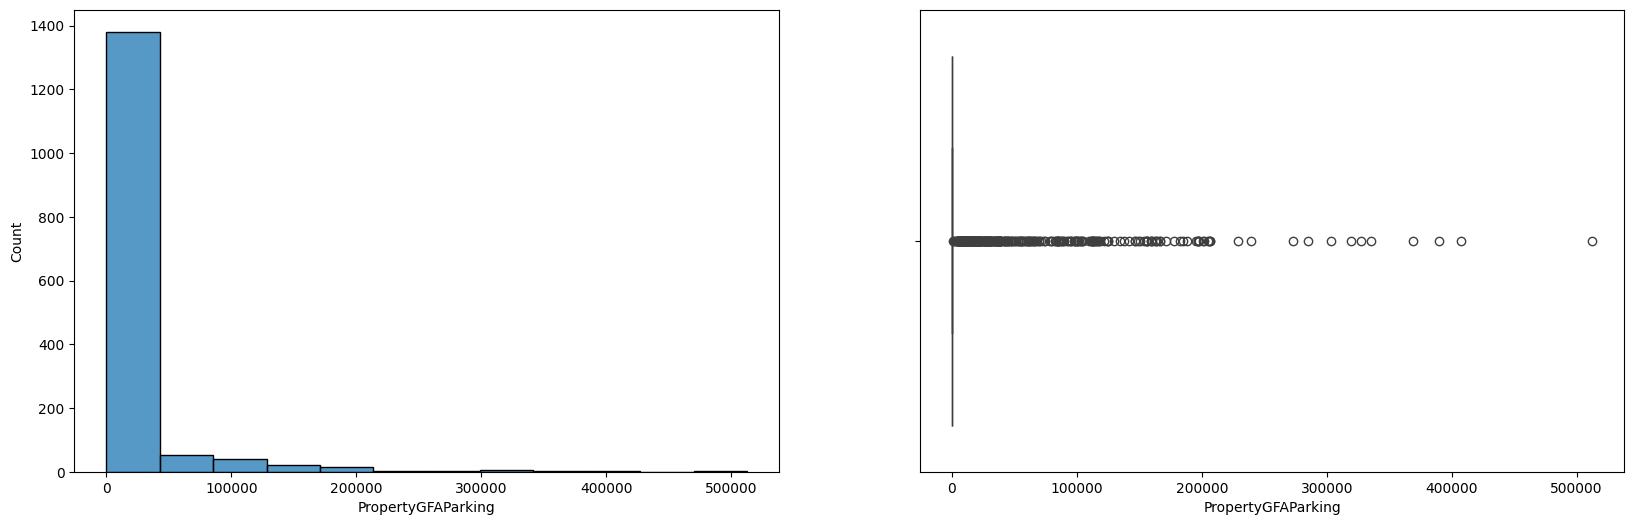

In [1542]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['PropertyGFAParking'])
plt.subplot(1,2,2)
sns.boxplot(x=df['PropertyGFAParking'])

In [1543]:
# df.drop(index = df[df['PropertyGFAParking']>50000].index,inplace=True)
# df.shape

<Axes: xlabel='PropertyGFAParking'>

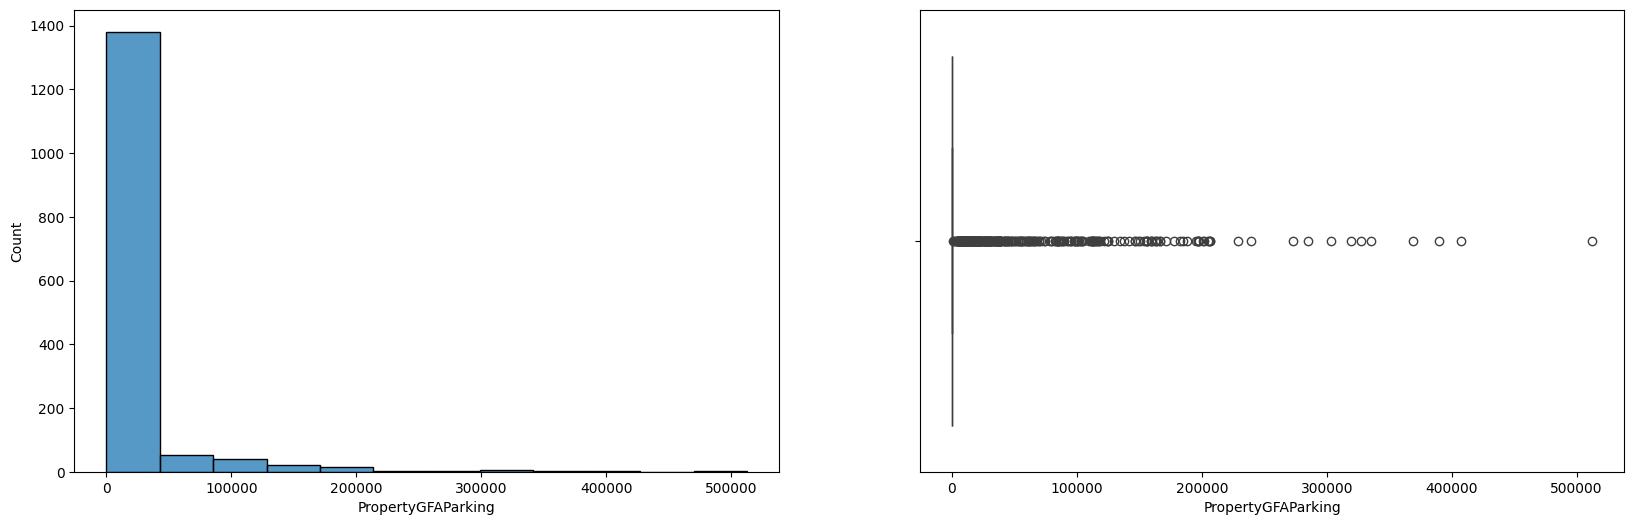

In [1544]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['PropertyGFAParking'])
plt.subplot(1,2,2)
sns.boxplot(x=df['PropertyGFAParking'])

### PLOT : Distribution NumberofFloors

<Axes: xlabel='NumberofFloors'>

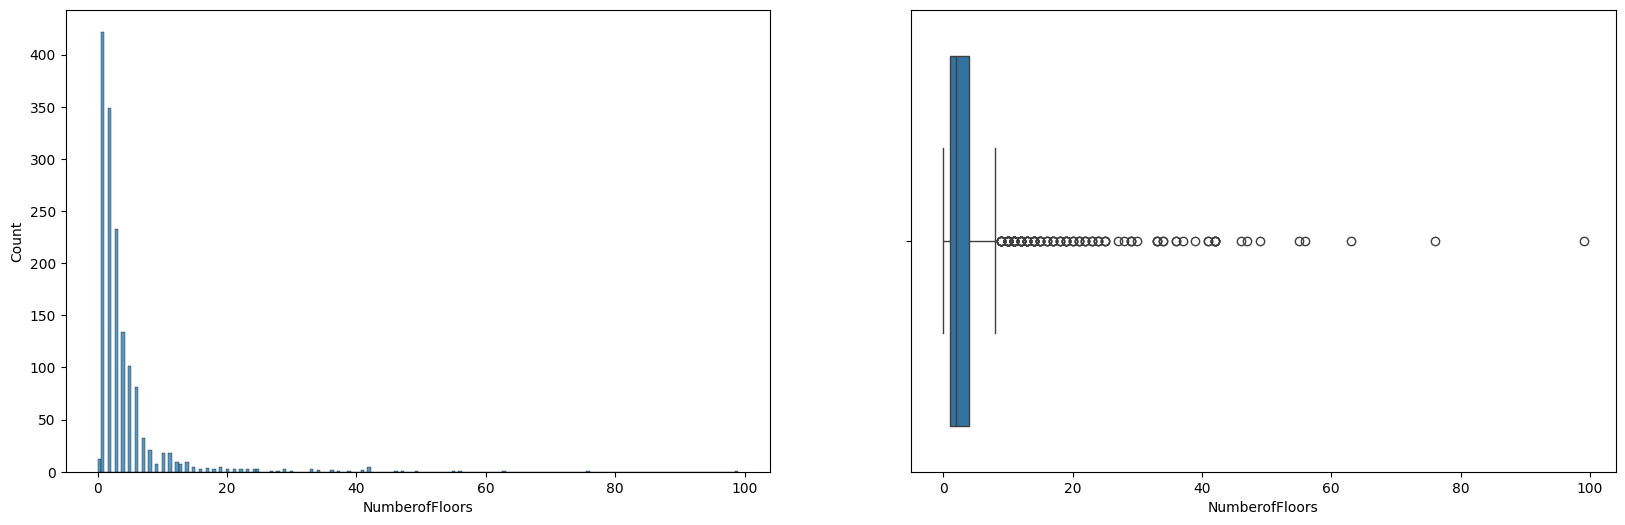

In [1545]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['NumberofFloors'])
plt.subplot(1,2,2)
sns.boxplot(x=df['NumberofFloors'])

In [1546]:
df.drop(index = df[df['NumberofFloors']>60].index,inplace=True)#45
df.shape

(1518, 25)

<Axes: xlabel='NumberofFloors'>

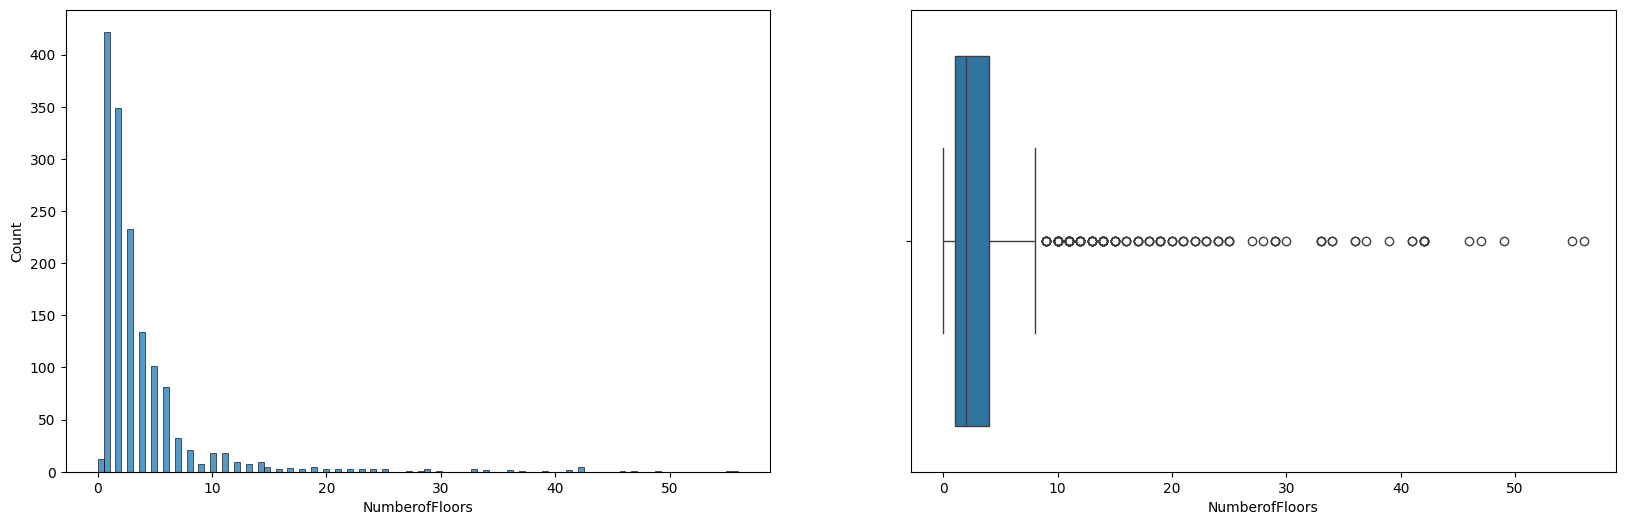

In [1547]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['NumberofFloors'])
plt.subplot(1,2,2)
sns.boxplot(x=df['NumberofFloors'])

### PLOT : Distribution NumberofBuildings

<Axes: xlabel='NumberofBuildings'>

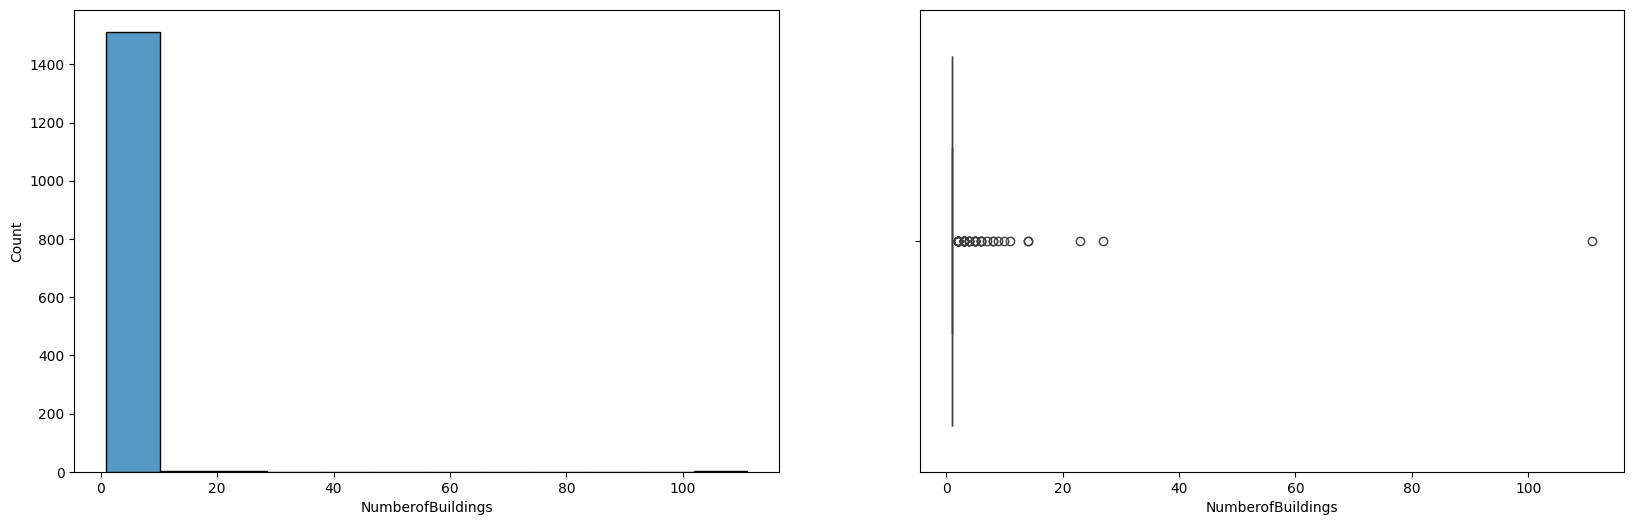

In [1548]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['NumberofBuildings'])
plt.subplot(1,2,2)
sns.boxplot(x=df['NumberofBuildings'])

In [1549]:
df.drop(index = df[df['NumberofBuildings']>20].index,inplace=True)#40
df.shape

(1515, 25)

<Axes: xlabel='NumberofBuildings'>

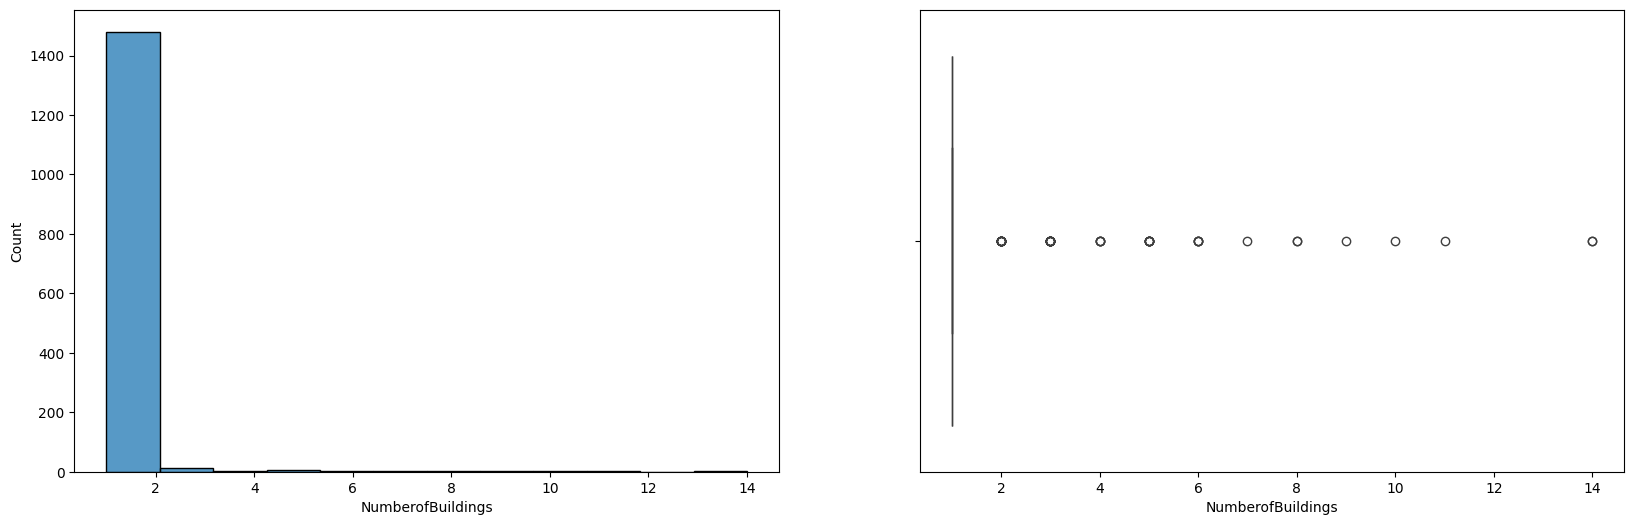

In [1550]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['NumberofBuildings'])
plt.subplot(1,2,2)
sns.boxplot(x=df['NumberofBuildings'])

### PLOT : Distribution NumberofBuildings

In [1551]:
df['parking_ratio'] = df.apply(lambda row : row['PropertyGFAParking']/row['PropertyGFATotal'],axis = 1)

<Axes: xlabel='parking_ratio'>

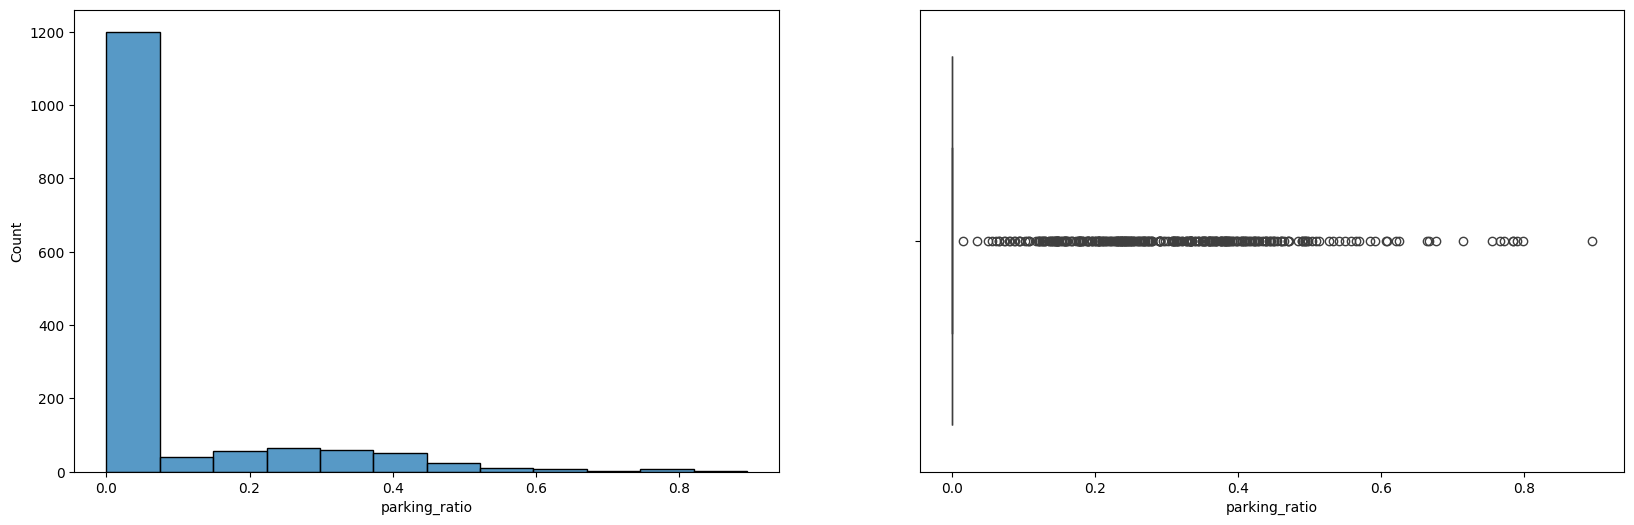

In [1552]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['parking_ratio'])
plt.subplot(1,2,2)
sns.boxplot(x=df['parking_ratio'])

In [1553]:
# df.drop(index = df[df['parking_ratio']>0.8].index,inplace=True)
# df.shape

<Axes: xlabel='parking_ratio'>

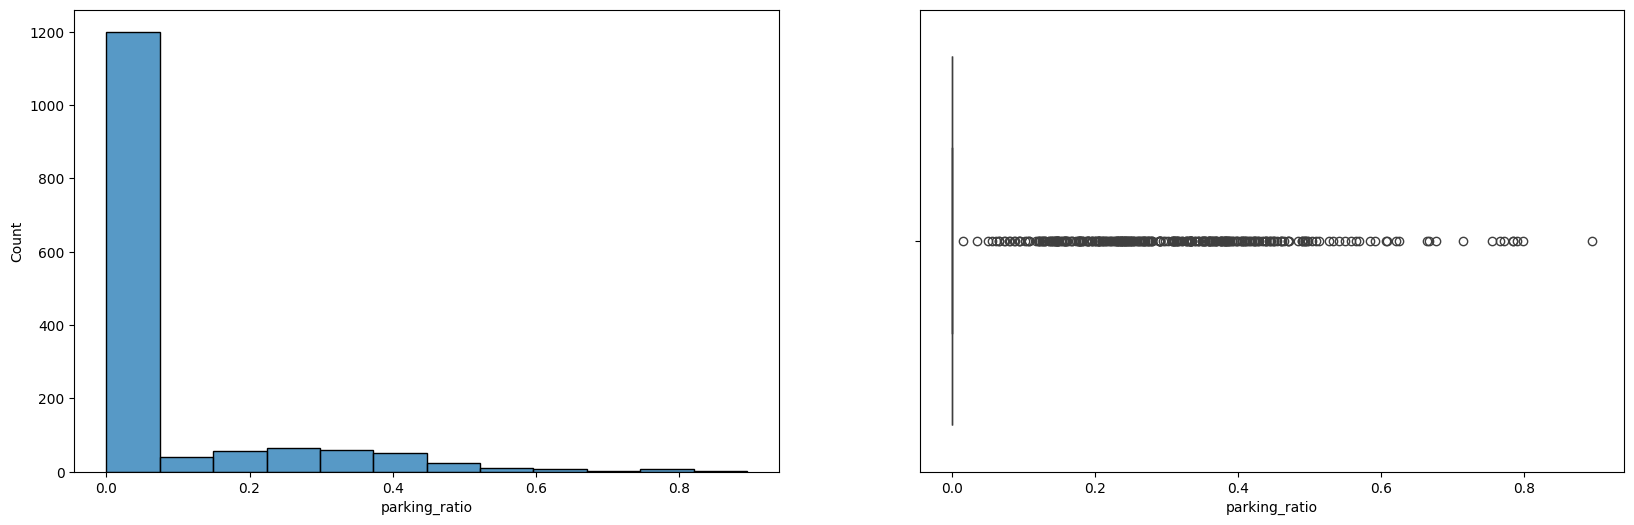

In [1554]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['parking_ratio'])
plt.subplot(1,2,2)
sns.boxplot(x=df['parking_ratio'])

### PLOT : Distribution TotalGHGEmissions

<Axes: xlabel='TotalGHGEmissions'>

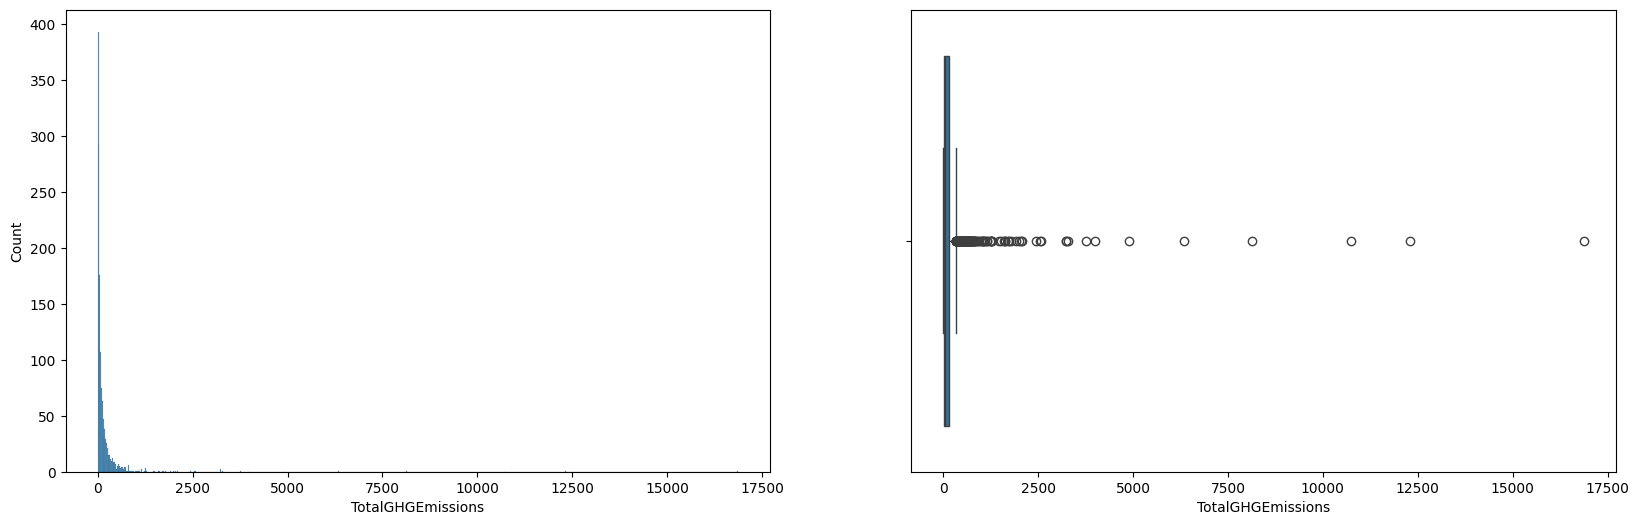

In [1555]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['TotalGHGEmissions'])
plt.subplot(1,2,2)
sns.boxplot(x=df['TotalGHGEmissions'])

In [1556]:
# df.drop(index = df[df['TotalGHGEmissions']>700].index,inplace=True)#5000
# df.shape

<Axes: xlabel='TotalGHGEmissions'>

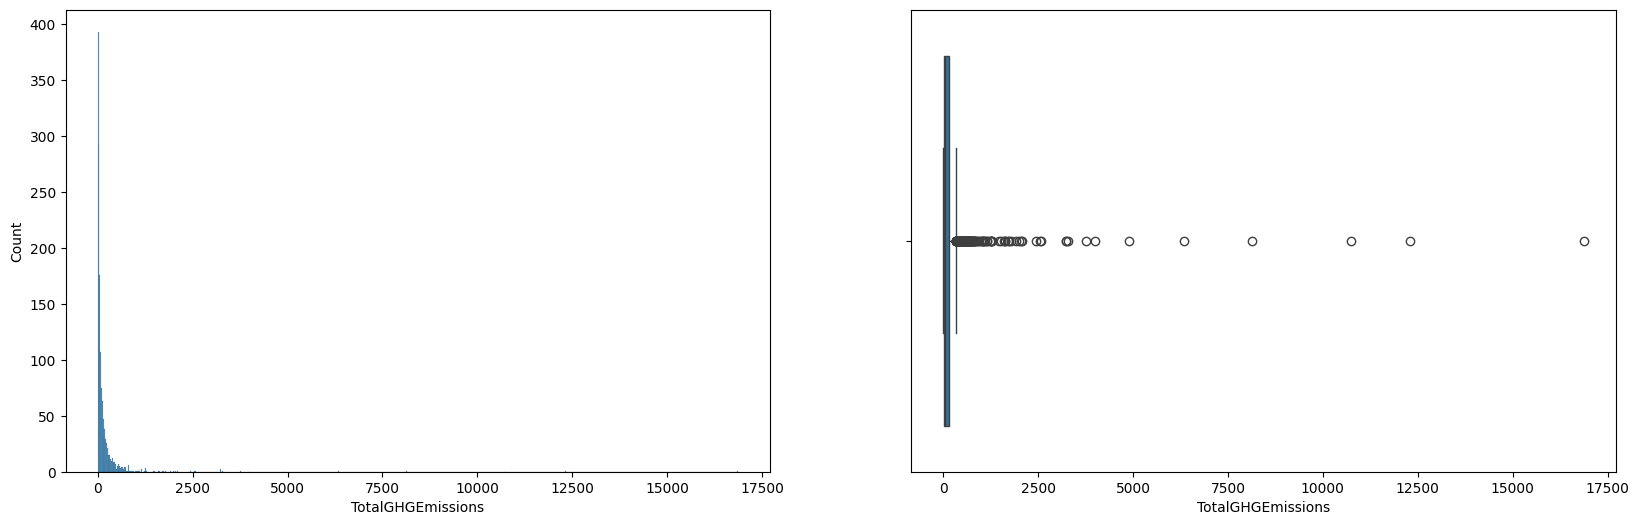

In [1557]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['TotalGHGEmissions'])
plt.subplot(1,2,2)
sns.boxplot(x=df['TotalGHGEmissions'])

### PLOT : Distribution PropertyGFABuilding

<Axes: xlabel='PropertyGFABuilding(s)'>

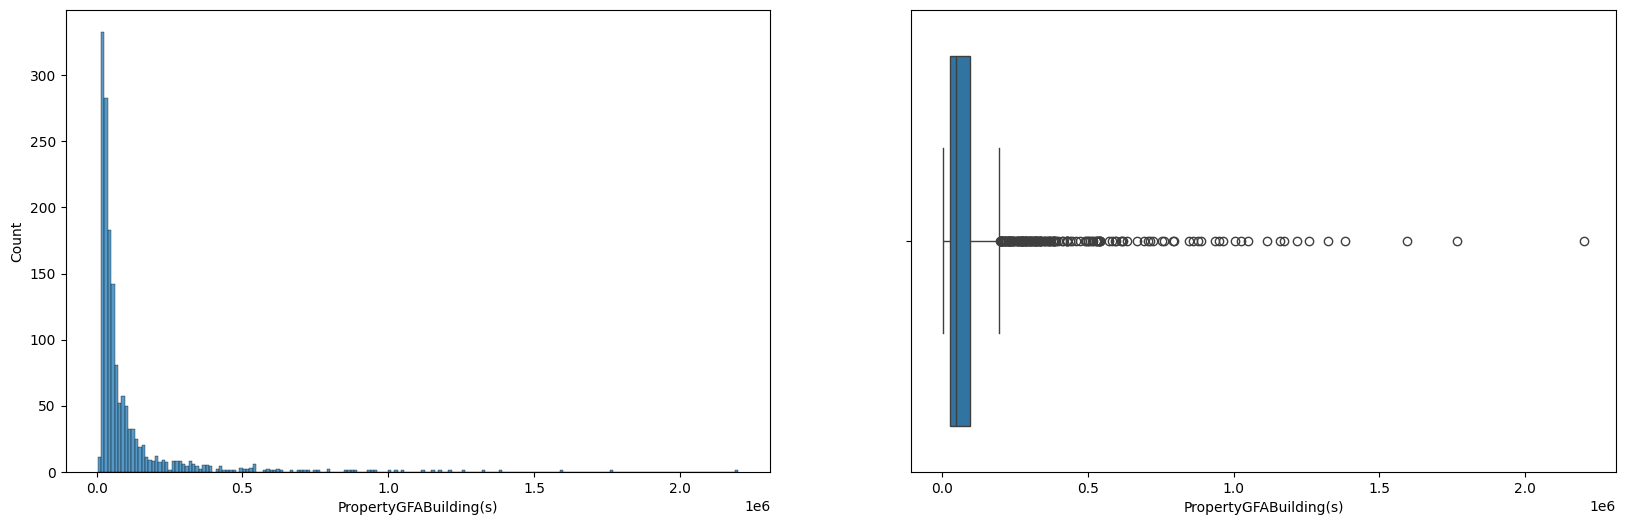

In [1558]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['PropertyGFABuilding(s)'])
plt.subplot(1,2,2)
sns.boxplot(x=df['PropertyGFABuilding(s)'])

In [1559]:
df.drop(index = df[df['PropertyGFABuilding(s)']>250000].index,inplace=True)#400000
df.shape

(1383, 26)

<Axes: xlabel='PropertyGFABuilding(s)'>

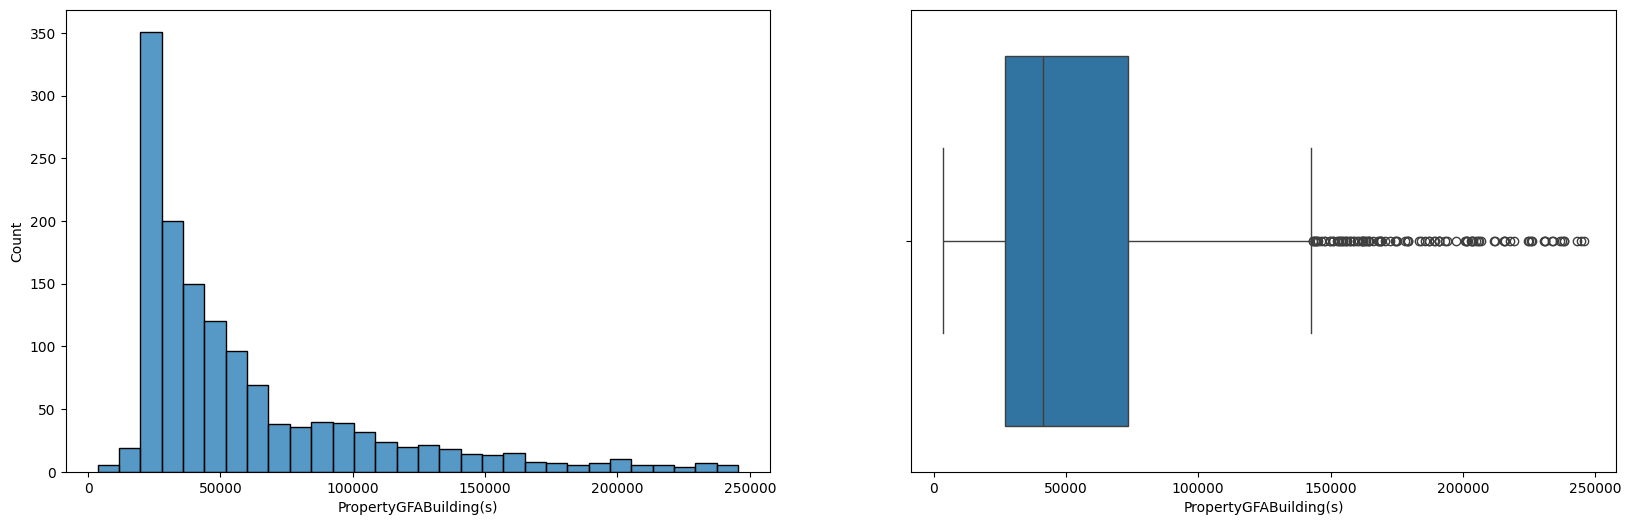

In [1560]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['PropertyGFABuilding(s)'])
plt.subplot(1,2,2)
sns.boxplot(x=df['PropertyGFABuilding(s)'])

### Suppression building à faible electricité

<Axes: xlabel='Electricity(kBtu)'>

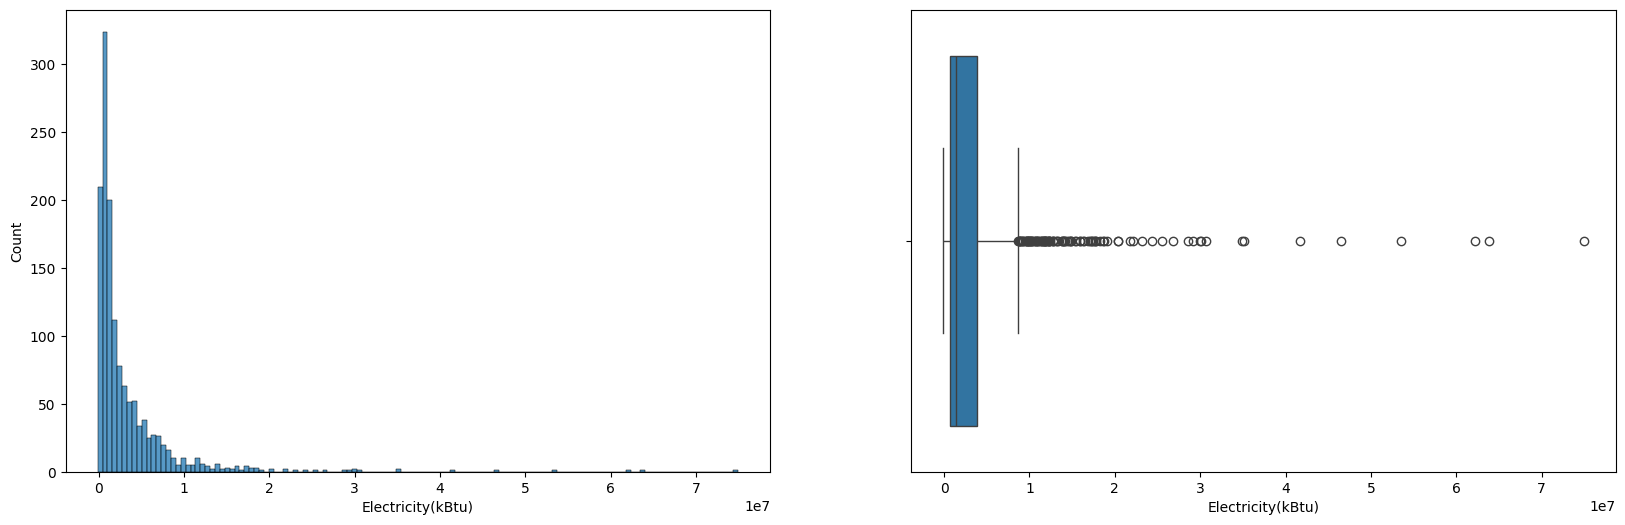

In [1561]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['Electricity(kBtu)'])
plt.subplot(1,2,2)
sns.boxplot(x=df['Electricity(kBtu)'])

In [1562]:
df.drop(index = df[(df['Electricity(kBtu)']<=0)].index,inplace=True)#| (df['Electricity(kBtu)']>12500000)
df.shape

(1380, 26)

<Axes: xlabel='Electricity(kBtu)'>

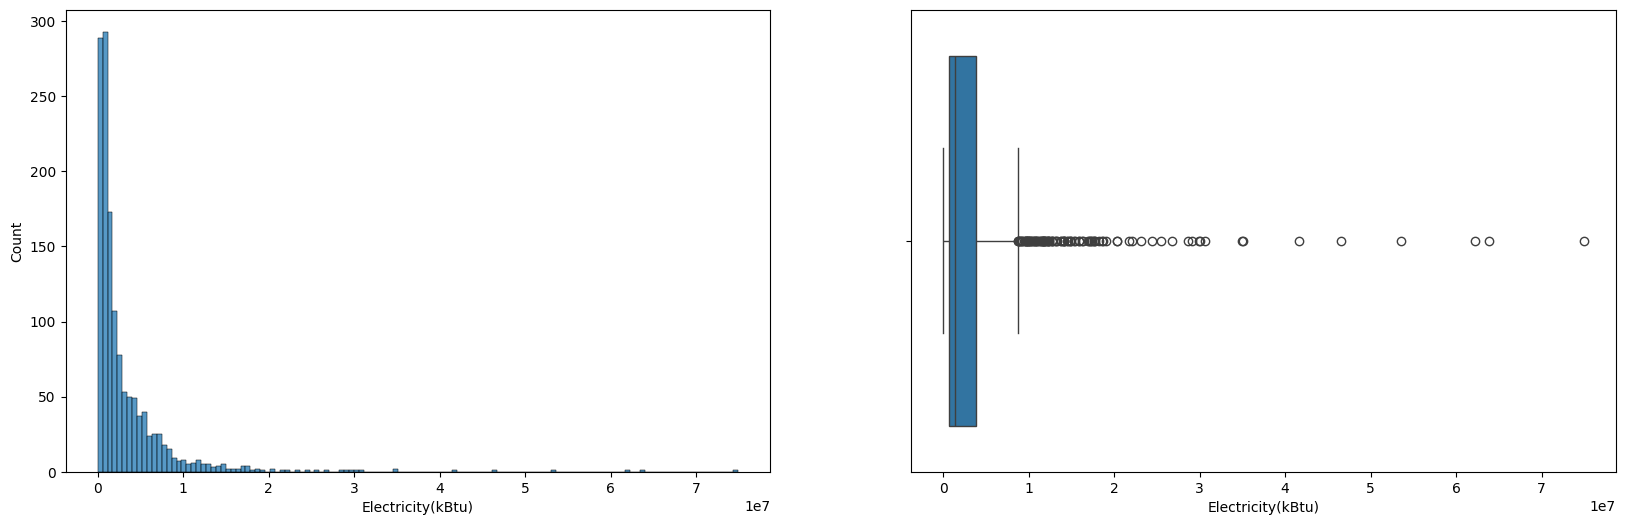

In [1563]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.histplot(x=df['Electricity(kBtu)'])
plt.subplot(1,2,2)
sns.boxplot(x=df['Electricity(kBtu)'])

## Analyse des batiments multiusages

In [1564]:
def calcul_multiusage(row):
    if pd.notna(row['ThirdLargestPropertyUseType']):
        return 3
    elif pd.notna(row['SecondLargestPropertyUseType']):
        return 2
    else:
        return 1

df['multiusage'] = df.apply(calcul_multiusage, axis=1)


### PLOT : Number of buildings

<Axes: xlabel='NumberofBuildings', ylabel='GHGEmissionsIntensity'>

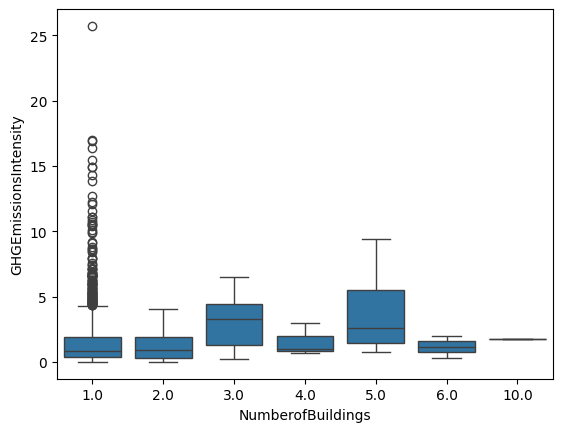

In [1565]:
sns.boxplot(data= df, x='NumberofBuildings',y='GHGEmissionsIntensity')

### PLOT : multiusage

<Axes: xlabel='multiusage', ylabel='TotalGHGEmissions'>

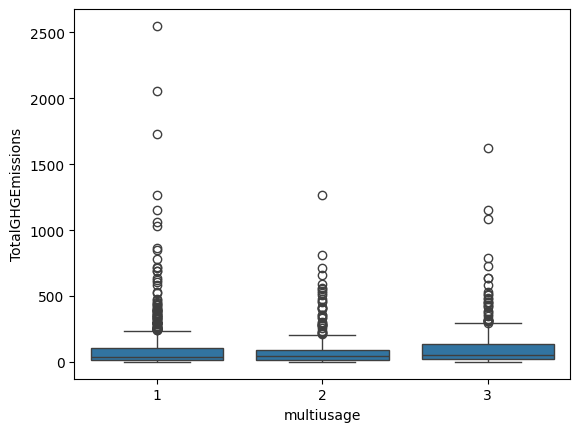

In [1566]:
sns.boxplot(data=df,x='multiusage',y='TotalGHGEmissions')

### PLOT : PropertyGFABuilding

In [1567]:

# # Définir les bornes des tranches (par exemple jusqu'à 100 000 m²)
# bins = range(0, df['PropertyGFABuilding(s)'].max() + 100000, 100000)
# df_tranche = df.copy()
# # Créer les tranches
# df_tranche['tranche_surface'] = pd.cut(df_tranche['PropertyGFABuilding(s)'], bins=bins, right=False)

# # Calculer la moyenne des émissions par tranche
# resultat = df_tranche.groupby(['tranche_surface','multiusage'])['TotalGHGEmissions'].mean().reset_index(name='em_moyenne')
# resultat
# sns.barplot(data=resultat,x='tranche_surface',y='em_moyenne',hue='multiusage')

## Analyse des redundances

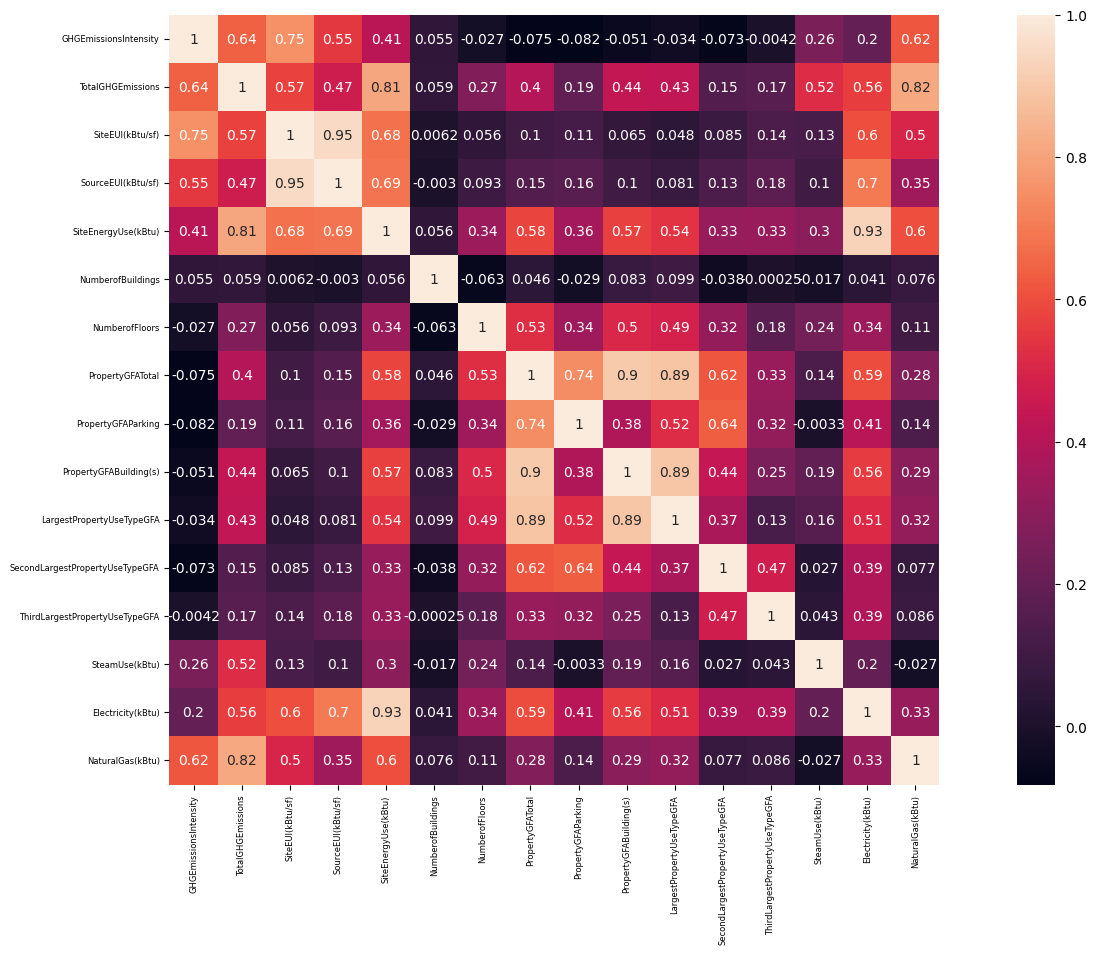

In [1568]:
Valeurs_numeriques = ['GHGEmissionsIntensity','TotalGHGEmissions','SiteEUI(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SiteEnergyUse(kBtu)','NumberofBuildings', 'NumberofFloors',
       'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
        'LargestPropertyUseTypeGFA',
        'SecondLargestPropertyUseTypeGFA',
        'ThirdLargestPropertyUseTypeGFA',
       
       'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)',
        ]

corrmat = df[Valeurs_numeriques].corr()
plt.figure(figsize=(20,10))
sns.heatmap(corrmat, annot=True, square=True)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.show()

In [1569]:
redundance = ['SourceEUI(kBtu/sf)', 'PropertyGFATotal']
df.drop(redundance,axis=1, inplace=True)
df.shape

(1380, 25)

# Modélisation 

## Import des modules 

In [1570]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
    KFold
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor


## Feature Engineering

### HasEnergies

In [1571]:
df['HasGas'] = df.apply(lambda row : 1 if row['NaturalGas(kBtu)']>0 else 0,axis = 1)
df.shape

(1380, 26)

In [1572]:
df['HasSteam'] = df.apply(lambda row : 1 if row['SteamUse(kBtu)']>0 else 0,axis = 1)
df.shape

(1380, 27)

In [1573]:
df['HasElectricity'] = df.apply(lambda row : 1 if row['Electricity(kBtu)']>0 else 0,axis = 1)
df.shape

(1380, 28)

### Age building 

In [1574]:
df['ageBuilding'] = df.apply(lambda row : 2025 - row['YearBuilt'],axis=1)
df.drop('YearBuilt',axis=1,inplace=True)
df.shape

(1380, 28)

### Surface moyenne prise en au sol / par étage

In [1575]:
df['sf_floor'] = df.apply(lambda row : row['PropertyGFABuilding(s)']/(row['NumberofFloors']+1) ,axis=1)
df.shape

(1380, 29)

## DATALEAKAGE

### Energies 

In [1576]:
energies_dataleakage = ['SiteEUI(kBtu/sf)','SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)',]
df.drop(energies_dataleakage,axis=1,inplace=True)
df.shape

(1380, 25)

## Valeurs cibles

In [1577]:
#'TotalGHGEmissions', 'SiteEnergyUse(kBtu)'
df.drop('GHGEmissionsIntensity',axis=1,inplace=True)
df.shape


(1380, 24)

In [1578]:
df.head()

,CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions,parking_ratio,multiusage,HasGas,HasSteam,HasElectricity,ageBuilding,sf_floor
0,7,DOWNTOWN,47.61220,-122.33799,1.0,12,0,88434,Hotel,88434.0,NaN,0.0,NaN,0.0,60.000000,7226362.5,249.98,0.000000,1,1,1,1,98,6802.615385
1,7,DOWNTOWN,47.61317,-122.33393,1.0,11,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant/Food,4622.0,61.000000,8387933.0,295.86,0.145453,3,1,0,1,29,7375.166667
3,7,DOWNTOWN,47.61412,-122.33664,1.0,10,0,61320,Hotel,61320.0,NaN,0.0,NaN,0.0,56.000000,6794584.0,286.43,0.000000,1,1,1,1,99,5574.545455
4,7,DOWNTOWN,47.61375,-122.34047,1.0,18,62000,113580,Hotel,123445.0,Parking,68009.0,Fitness,0.0,75.000000,14172606.0,505.01,0.353115,3,1,0,1,45,5977.894737
5,7,DOWNTOWN,47.61623,-122.33657,1.0,2,37198,60090,Public Services,88830.0,NaN,0.0,NaN,0.0,42.207197,12086616.0,301.81,0.382349,1,1,0,1,26,20030.000000


## Encodage

In [1579]:
# df = pd.get_dummies(df,columns=['Neighborhood'])
df = pd.get_dummies(df,columns=['LargestPropertyUseType'])
# df = pd.get_dummies(df,columns=['SecondLargestPropertyUseType'])
# df = pd.get_dummies(df,columns=['ThirdLargestPropertyUseType'])
df.shape

(1380, 43)

In [1580]:
df.drop(['SecondLargestPropertyUseType','ThirdLargestPropertyUseType','Neighborhood'], inplace=True, axis=1)

## Cible 'SiteEnergyUse(kBtu)'

### Séparation X_energy, y_energy

In [1581]:
y_energy = df['SiteEnergyUse(kBtu)'].copy()
X = df.copy().drop(['SiteEnergyUse(kBtu)','TotalGHGEmissions'], axis=1)

### Train test split

In [1582]:
X_energy_train, X_energy_test, y_energy_train, y_energy_test = train_test_split(X, y_energy, random_state=42,test_size=0.2)

### Colonnes numériques

In [1583]:
numerical_columns = ['NumberofBuildings', 'ENERGYSTARScore','sf_floor','Latitude','Longitude',
       'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ageBuilding']

### Standardisation

In [1584]:
y_scaler = StandardScaler()


for column in numerical_columns:
    scaler = StandardScaler()
    
    # Transformer X_train
    X_energy_train[column] = pd.Series(
        scaler.fit_transform(X_energy_train[column].to_numpy().reshape(-1, 1)).flatten(),
        index=X_energy_train.index
    )
    
    # Transformer X_test
    X_energy_test[column] = pd.Series(
        scaler.transform(X_energy_test[column].to_numpy().reshape(-1, 1)).flatten(),
        index=X_energy_test.index
    )


y_energy_train=pd.DataFrame(
    y_scaler.fit_transform(y_energy_train.to_numpy().reshape(-1, 1)),
    columns=['SiteEnergyUse(kBtu)'],
    index=y_energy_train.index)


y_energy_test=pd.DataFrame(
    y_scaler.transform(y_energy_test.to_numpy().reshape(-1, 1)),
    columns=['SiteEnergyUse(kBtu)'],
    index=y_energy_test.index)

### Models

In [1585]:
df_total = pd.DataFrame(columns=['nom_model','r2', 'MAE','MSE'])

#### Kfold

In [1586]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

#### DummyRegressor

In [1587]:
dummy_model = DummyRegressor(strategy='mean')
cv = cross_validate(dummy_model,X_energy_train,y_energy_train,cv=kf,verbose=1,n_jobs=-1,scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'])
df_cv = pd.DataFrame(cv)
df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['dummy_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.0s finished
C:\Users\Fabien\AppData\Local\Temp\ipykernel_28884\4120517335.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['dummy_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])


#### RidgeRegressor

In [1588]:
Ridge_model = Ridge(random_state=42)
cv = cross_validate(Ridge_model,X_energy_train,y_energy_train,cv=kf,verbose=1,n_jobs=-1,scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'])
df_cv = pd.DataFrame(cv)
df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['Ridge_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.0s finished


#### RandomForestRegressor

In [1589]:
RandomForest_model = RandomForestRegressor(random_state=42)
cv = cross_validate(RandomForest_model,X_energy_train,y_energy_train,cv=kf,verbose=1,n_jobs=-1,scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'])
df_cv = pd.DataFrame(cv)
df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['RandomForest_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    2.5s finished


#### GradientBoostingRegressor

In [1590]:
GradientBoosting_model = GradientBoostingRegressor(random_state=42)
cv = cross_validate(GradientBoosting_model,X_energy_train,y_energy_train,cv=kf,verbose=1,n_jobs=-1,scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'])
df_cv = pd.DataFrame(cv)
df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['GradientBoosting_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.9s finished


#### Comparaison model energy

In [1591]:
df_total

,nom_model,r2,MAE,MSE
0,dummy_model,-0.019919,-0.568755,-1.001533
0,Ridge_model,0.410192,-0.383959,-0.562318
0,RandomForest_model,0.402995,-0.328373,-0.566700
0,GradientBoosting_model,0.408582,-0.329417,-0.539201


## Cible 'TotalGHGEmissions'

In [1592]:
df_total = df_total[0:0]

### Séparation X_CO2, y_CO2

In [1593]:
y_CO2 = df['TotalGHGEmissions'].copy()

### Train test split

In [1594]:
X_CO2_train, X_CO2_test, y_CO2_train, y_CO2_test = train_test_split(X, y_CO2, random_state=42, test_size=0.2)

### Standardisation

In [1595]:
y_scaler = StandardScaler()


for column in numerical_columns:
    scaler = StandardScaler()
    
    # Transformer X_train
    X_CO2_train[column] = pd.Series(
        scaler.fit_transform(X_CO2_train[column].to_numpy().reshape(-1, 1)).flatten(),
        index=X_CO2_train.index
    )
    
    # Transformer X_test
    X_CO2_test[column] = pd.Series(
        scaler.transform(X_CO2_test[column].to_numpy().reshape(-1, 1)).flatten(),
        index=X_CO2_test.index
    )

y_CO2_train=pd.DataFrame(
    y_scaler.fit_transform(y_CO2_train.to_numpy().reshape(-1, 1)),
    columns=['TotalGHGEmissions'],
    index=y_CO2_train.index)


y_CO2_test=pd.DataFrame(
    y_scaler.transform(y_CO2_test.to_numpy().reshape(-1, 1)),
    columns=['TotalGHGEmissions'],
    index=y_CO2_test.index)

### Models

#### DummyRegressor

In [1596]:
dummy_model = DummyRegressor(strategy='mean')
cv = cross_validate(dummy_model,X_CO2_train,y_CO2_train,cv=kf,verbose=1,n_jobs=-1,scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'])
df_cv = pd.DataFrame(cv)
df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['dummy_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.0s finished


#### RidgeRegressor

In [1597]:
Ridge_model = Ridge(random_state=42)
cv = cross_validate(Ridge_model,X_CO2_train,y_CO2_train,cv=kf,verbose=1,n_jobs=-1,scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'])
df_cv = pd.DataFrame(cv)
df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['Ridge_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.0s finished


#### RandomForestRegressor

In [1598]:
RandomForest_model = RandomForestRegressor(random_state=42)
cv = cross_validate(RandomForest_model,X_CO2_train,y_CO2_train,cv=kf,verbose=1,n_jobs=-1,scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'])
df_cv = pd.DataFrame(cv)
df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['RandomForest_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    2.9s finished


#### GradientBoostingRegressor

In [1599]:
GradientBoosting_model = GradientBoostingRegressor(random_state=42)
cv = cross_validate(GradientBoosting_model,X_CO2_train,y_CO2_train,cv=kf,verbose=1,n_jobs=-1,scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'])
df_cv = pd.DataFrame(cv)
df_total =pd.concat([df_total, pd.DataFrame({'nom_model': ['GradientBoosting_model'],'r2':[df_cv['test_r2'].mean()],'MAE':[df_cv['test_neg_mean_absolute_error'].mean()],'MSE':[df_cv['test_neg_mean_squared_error'].mean()]})])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.9s finished


#### Comparaison model CO2

In [1600]:
df_total

,nom_model,r2,MAE,MSE
0,dummy_model,-0.022083,-0.589564,-1.000908
0,Ridge_model,0.367032,-0.438218,-0.601519
0,RandomForest_model,0.349936,-0.387897,-0.630743
0,GradientBoosting_model,0.202790,-0.404134,-0.720269


# Optimisation modèles

## Cible 'SiteEnergyUse(kBtu)'

### GridSearchCV sur GradientBoosting

In [1601]:
params = {
    'n_estimators' :[350,400,600],
    'max_depth':[None,3,4],
    'min_samples_split':[2], 
    'min_samples_leaf' : [2], 
    'max_features':['sqrt'],
    'max_leaf_nodes':[None,10],    

}
GradientBoosting_model_Energy = GradientBoostingRegressor(random_state=42)
GSCV = GridSearchCV(GradientBoosting_model_Energy,n_jobs=-1, verbose=1, cv=kf, param_grid=params,scoring='r2')
GSCV.fit(X_energy_train,y_energy_train.values.ravel())
best_params = GSCV.best_params_
# best_params= {'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
print(best_params)


Fitting 10 folds for each of 18 candidates, totalling 180 fits
{'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 350}


### Entrainement modèle avec les bests_parameters

In [1602]:
GradientBoosting_model_Energy=GradientBoostingRegressor(**best_params,random_state=42)#**best_params,
GradientBoosting_model_Energy.fit(X_energy_train,y_energy_train)
y_pred = GradientBoosting_model_Energy.predict(X_energy_test)

c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


###  Identification meilleurs variables

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'PropertyGFABuilding(s)'),
  Text(1, 0, 'LargestPropertyUseTypeGFA'),
  Text(2, 0, 'ENERGYSTARScore'),
  Text(3, 0, 'NumberofFloors'),
  Text(4, 0, 'LargestPropertyUseType_Science/Technology'),
  Text(5, 0, 'ThirdLargestPropertyUseTypeGFA'),
  Text(6, 0, 'PropertyGFAParking'),
  Text(7, 0, 'sf_floor'),
  Text(8, 0, 'SecondLargestPropertyUseTypeGFA'),
  Text(9, 0, 'Latitude'),
  Text(10, 0, 'Longitude'),
  Text(11, 0, 'ageBuilding'),
  Text(12, 0, 'parking_ratio'),
  Text(13, 0, 'LargestPropertyUseType_Office'),
  Text(14, 0, 'CouncilDistrictCode'),
  Text(15, 0, 'LargestPropertyUseType_Specialty/Other'),
  Text(16, 0, 'LargestPropertyUseType_Warehouse'),
  Text(17, 0, 'LargestPropertyUseType_Healthcare'),
  Text(18, 0, 'multiusage'),
  Text(19, 0, 'LargestPropertyUseType_Retail')])

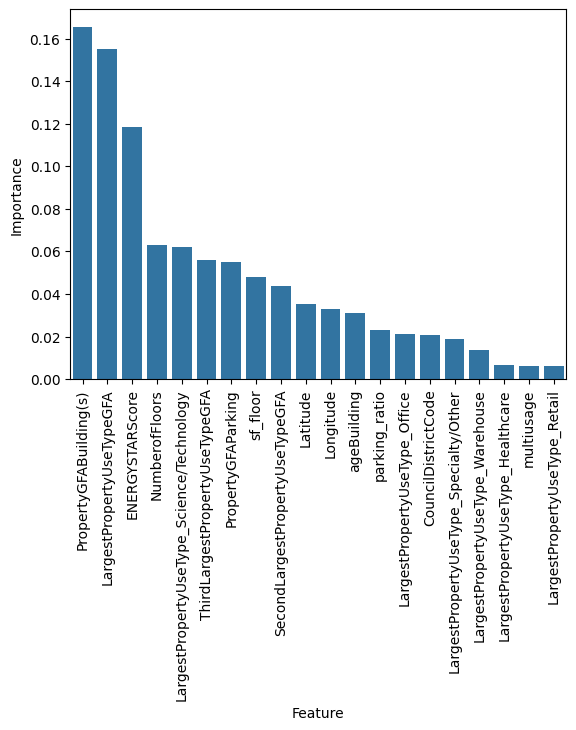

In [1603]:
GradientBoosting_model_Energy.feature_importances_
df_importances =pd.DataFrame({'Feature':X_energy_train.columns, 'Importance': GradientBoosting_model_Energy.feature_importances_}).sort_values(by='Importance',ascending=False)
sns.barplot(data= df_importances.iloc[:20,:],x='Feature', y='Importance')
plt.xticks(rotation=90)

### Scoring et comparaison pred/truth

In [1604]:
print(f'MSE : {mean_squared_error(y_true=y_energy_test,y_pred=y_pred)} | r² : {r2_score(y_true=y_energy_test,y_pred=y_pred)} | MAE : {mean_absolute_error(y_true=y_energy_test,y_pred=y_pred)}')

MSE : 0.7308618367403034 | r² : 0.5545251117950478 | MAE : 0.4074159669938429


## Cible 'TotalGHGEmissions'

### gridsearchCV sur Randomforest

In [1605]:
params = {
    'n_estimators' :[250,300,350],
    'max_depth':[None,3,4],
    'min_samples_split':[2], 
    'min_samples_leaf' : [1], 
    'max_features':['sqrt'],
    'max_leaf_nodes':[None,20,30,40],    
    'max_samples':[20,30]
}
RandomForest_model_CO2 = RandomForestRegressor(random_state=42)
GSCV = GridSearchCV(RandomForest_model_CO2,n_jobs=-1, verbose=1, cv=kf, param_grid=params,scoring='r2')
GSCV.fit(X_CO2_train,y_energy_train.values.ravel())
best_params = GSCV.best_params_

Fitting 10 folds for each of 72 candidates, totalling 720 fits


In [1606]:
print(best_params)

{'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': 30, 'max_samples': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 350}


###  Identification meilleurs variables

### Entrainement modèle avec les bests_parameters

In [1607]:
RandomForest_model_CO2=RandomForestRegressor(random_state=42)#**best_params
RandomForest_model_CO2.fit(X_CO2_train,y_CO2_train)
y_pred =  RandomForest_model_CO2.predict(X_CO2_test)

c:\Users\Fabien\Desktop\OC\P3\SEATLE\env\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'PropertyGFABuilding(s)'),
  Text(1, 0, 'LargestPropertyUseTypeGFA'),
  Text(2, 0, 'LargestPropertyUseType_Science/Technology'),
  Text(3, 0, 'ENERGYSTARScore'),
  Text(4, 0, 'ageBuilding'),
  Text(5, 0, 'HasGas'),
  Text(6, 0, 'LargestPropertyUseType_Healthcare'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'sf_floor'),
  Text(9, 0, 'NumberofFloors'),
  Text(10, 0, 'Latitude'),
  Text(11, 0, 'PropertyGFAParking'),
  Text(12, 0, 'ThirdLargestPropertyUseTypeGFA'),
  Text(13, 0, 'SecondLargestPropertyUseTypeGFA'),
  Text(14, 0, 'parking_ratio'),
  Text(15, 0, 'HasSteam'),
  Text(16, 0, 'LargestPropertyUseType_Specialty/Other'),
  Text(17, 0, 'LargestPropertyUseType_Housing'),
  Text(18, 0, 'LargestPropertyUseType_Warehouse'),
  Text(19, 0, 'LargestPropertyUseType_Restaurant/Food')])

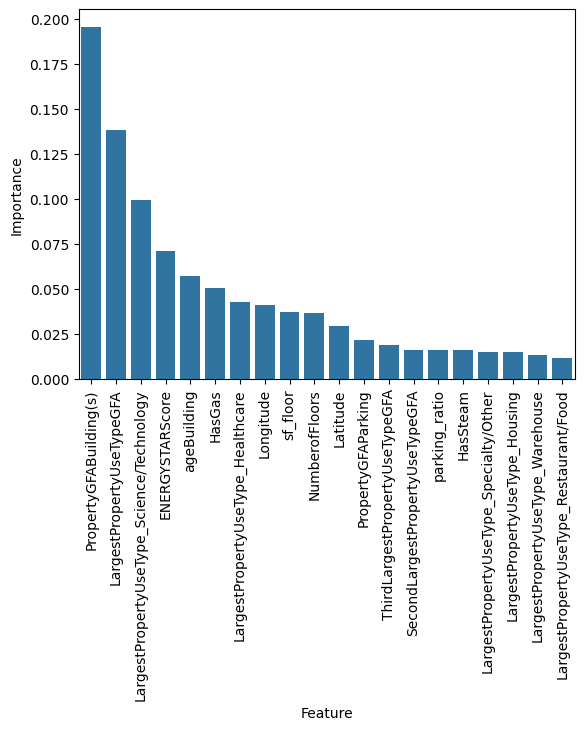

In [1608]:
RandomForest_model_CO2.feature_importances_
df_importances =pd.DataFrame({'Feature':X_energy_train.columns, 'Importance': RandomForest_model_CO2.feature_importances_}).sort_values(by='Importance',ascending=False)
sns.barplot(data= df_importances.iloc[:20,:],x='Feature', y='Importance')
plt.xticks(rotation=90)

### Scoring et comparaison pred/truth

In [1609]:
print(f'MSE : {mean_squared_error(y_energy_test,y_pred)} | r² : {r2_score(y_energy_test,y_pred)} | MAE : {mean_absolute_error(y_energy_test,y_pred)}')

MSE : 0.8145221482446158 | r² : 0.503532480847459 | MAE : 0.4669426594426918
